# Restricting the maximum neutron energy

This notebook demonstrates the `max_neutron_energy` parameter available on all
`unfold_*` methods. Setting it limits the unfolding algorithm so that no neutron
fluence is reconstructed above the specified energy — bins above the cutoff are
forced to zero.

Two strategies are used internally depending on the solver:

| Strategy | Applies to | How it works |
|----------|-----------|--------------|
| **UB array** | QP solvers (`cvxpy`, `qpsolvers`, `docplex`, `scip`, `mystic`) | Full response matrix is passed to the solver; an upper-bound array `ub` is set to 0 for bins above $E_{\max}$. |
| **Trimming** | Iterative / matrix solvers (`landweber`, `bunki`, `amaxed`, etc.) | Response matrix is sliced to active bins only; the result is expanded back to the full grid with zeros above $E_{\max}$. |

Both strategies produce the same physical result: **zero fluence above $E_{\max}$.**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from bssunfold import Detector, RF_LANL

## Load the LANL response functions and the IAEA reference Cf-252 spectrum

In [2]:
df_rf = pd.DataFrame.from_dict(RF_LANL, orient='columns')
det = Detector(df_rf)

reference_spectrum = pd.read_csv(
    '../tests/MonteCarlo_Calculated_spectra_from_IAEA_Comp_for_comparison.csv'
)
print(f'Detector grid: {det.n_energy_bins} bins, '
      f'{det.E_MeV[0]:.1e} – {det.E_MeV[-1]:.1f} MeV')
print(f'Reference CSV: {len(reference_spectrum)} rows')

Detector grid: 60 bins, 1.0e-09 – 631.0 MeV
Reference CSV: 61 rows


## Generate readings from the reference spectrum

`get_effective_readings_for_spectra` handles interpolation automatically
when the CSV energy grid does not match the detector grid.

In [16]:
readings = det.get_effective_readings_for_spectra(
    reference_spectrum[['E_MeV', 't4-14-s.txt_1']]
)

# Interpolate the reference spectrum onto the detector grid for plotting
spectrum_true = np.interp(det.E_MeV, reference_spectrum['E_MeV'].values,
                           reference_spectrum['t4-14-s.txt_1'].values)

print('Sample readings:')
for k, v in list(readings.items())[:12]:
    print(f'  {k:6s}: {v:.2f}')

Sample readings:
  3in   : 1.34
  4in   : 1.77
  5in   : 1.84
  6in   : 1.81
  8in   : 1.09
  9in   : 0.76
  12in  : 0.28
  18in  : 0.03
  9inPb : 0.94
  12inPb: 0.34
  18inPb: 0.06


## Choose the maximum neutron energies to demonstrate

The LANL grid spans from ~1 neV to ~630 MeV. We pick cutoff values that
illustrate progressively less restrictive limits:

In [24]:
emax_values = [1.0,5.0, 20.0, 100.0]

## 1. `unfold_qpsolvers` — QP solver with UB array

The QP approach receives the **full** response matrix. An upper-bound
vector is passed to the quadratic-programming backend; bins above $E_{\max}$
have `ub = 0`, so the solver itself enforces zero fluence there.

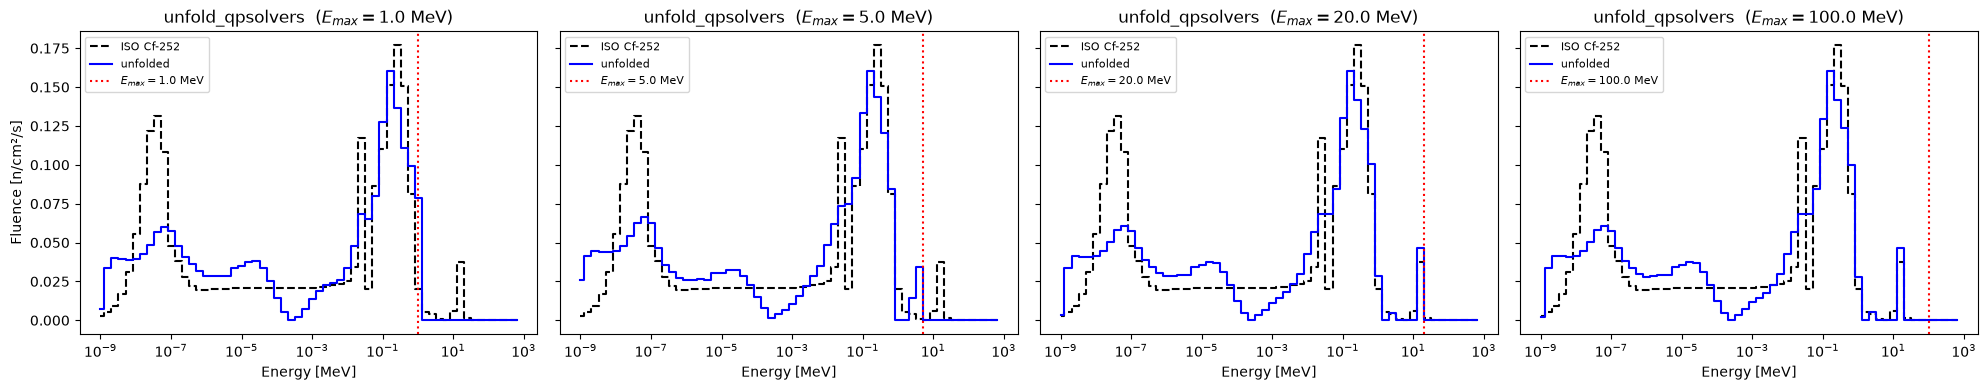

In [25]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4), sharey=True)
for ax, emax in zip(axes, emax_values):
    res = det.unfold_qpsolvers(readings, max_neutron_energy=emax, solver='osqp')
    ax.step(det.E_MeV, spectrum_true, 'k--', label='ISO Cf-252', where='mid')
    ax.step(det.E_MeV, res['spectrum'], 'b-', label='unfolded', where='mid')
    ax.axvline(emax, color='r', ls=':', lw=1.5, label=f'$E_{{max}}={emax}$ MeV')
    ax.set_xscale('log')
    ax.set_xlabel('Energy [MeV]')
    ax.set_title(f'unfold_qpsolvers  ($E_{{max}}={emax}$ MeV)')
    ax.legend(fontsize=8)
axes[0].set_ylabel('Fluence [n/cm²/s]')
fig.tight_layout()
plt.show()

## 2. `unfold_landweber` — iterative Landweber method (trimming)

Landweber uses the **trimming** strategy: the response matrix is sliced to
active energy bins only, the iteration runs on the reduced system, and the
result is expanded back with zeros above $E_{\max}$.

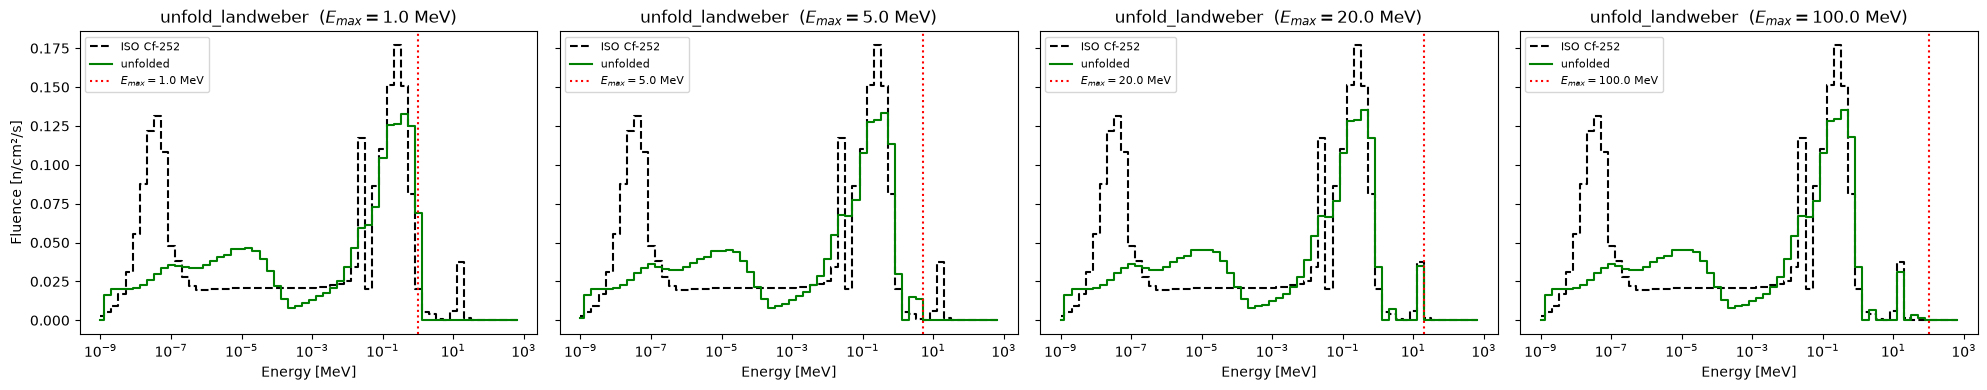

In [26]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4), sharey=True)
for ax, emax in zip(axes, emax_values):
    res = det.unfold_landweber(readings, max_neutron_energy=emax)
    ax.step(det.E_MeV, spectrum_true, 'k--', label='ISO Cf-252', where='mid')
    ax.step(det.E_MeV, res['spectrum'], 'g-', label='unfolded', where='mid')
    ax.axvline(emax, color='r', ls=':', lw=1.5, label=f'$E_{{max}}={emax}$ MeV')
    ax.set_xscale('log')
    ax.set_xlabel('Energy [MeV]')
    ax.set_title(f'unfold_landweber  ($E_{{max}}={emax}$ MeV)')
    ax.legend(fontsize=8)
axes[0].set_ylabel('Fluence [n/cm²/s]')
fig.tight_layout()
plt.show()

## 3. `unfold_bunki` — BUNKI / SPUNIT algorithm (trimming)

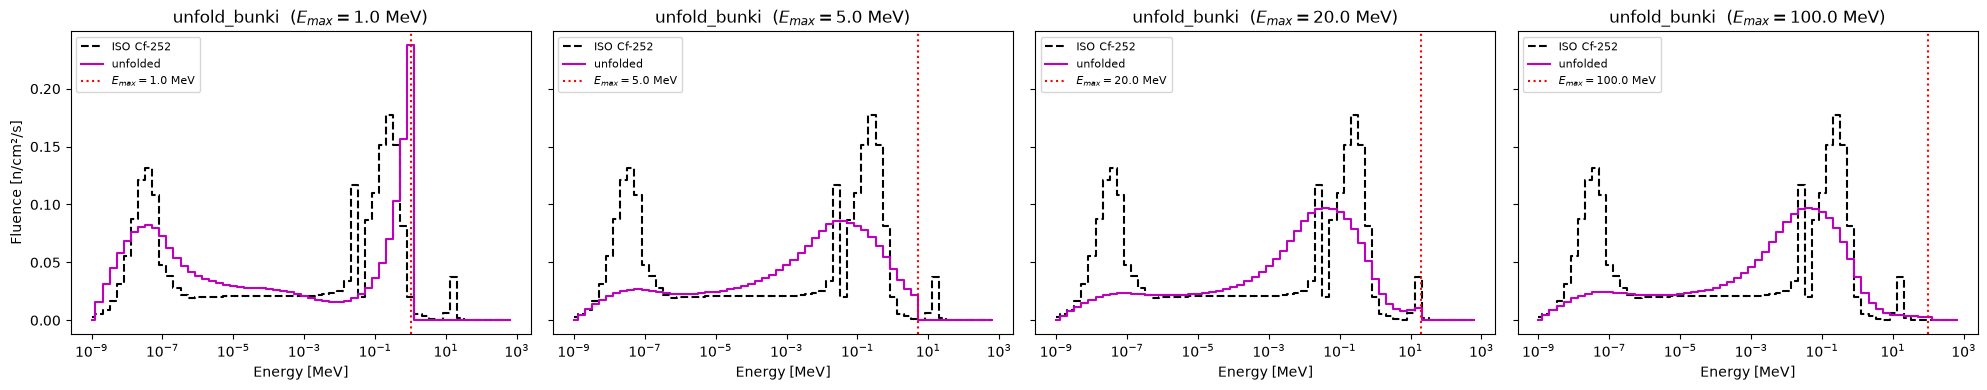

In [27]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4), sharey=True)
for ax, emax in zip(axes, emax_values):
    res = det.unfold_bunki(readings, max_neutron_energy=emax)
    ax.step(det.E_MeV, spectrum_true, 'k--', label='ISO Cf-252', where='mid')
    ax.step(det.E_MeV, res['spectrum'], 'm-', label='unfolded', where='mid')
    ax.axvline(emax, color='r', ls=':', lw=1.5, label=f'$E_{{max}}={emax}$ MeV')
    ax.set_xscale('log')
    ax.set_xlabel('Energy [MeV]')
    ax.set_title(f'unfold_bunki  ($E_{{max}}={emax}$ MeV)')
    ax.legend(fontsize=8)
axes[0].set_ylabel('Fluence [n/cm²/s]')
fig.tight_layout()
plt.show()

## 4. `unfold_amaxed` — AMAXED algorithm (trimming)

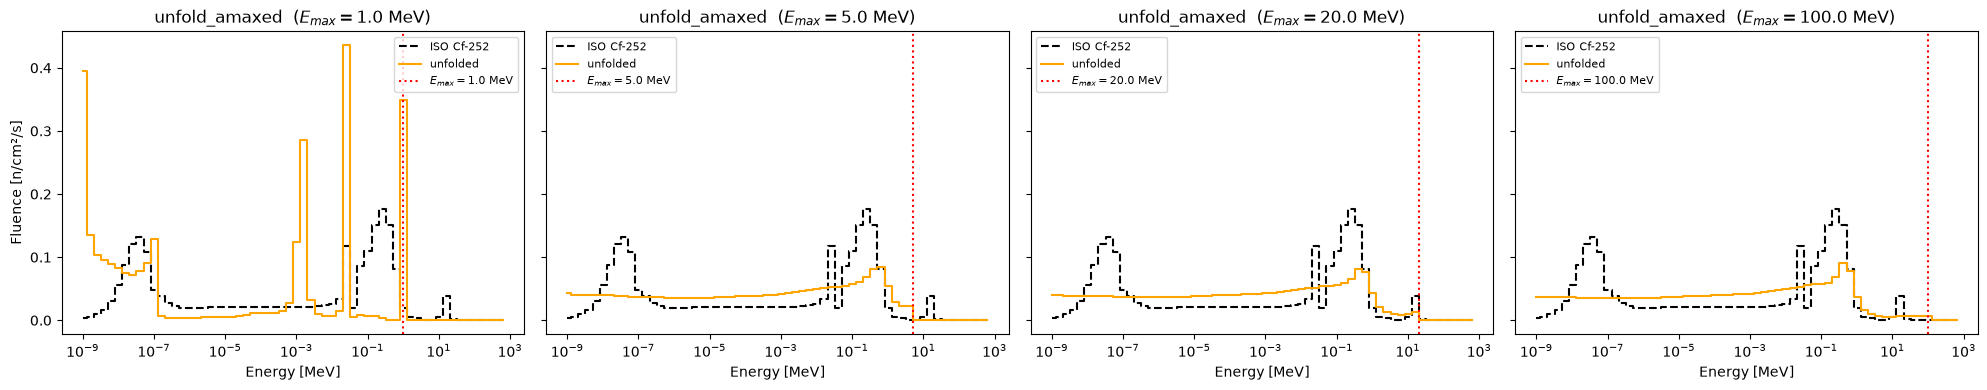

In [28]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4), sharey=True)
for ax, emax in zip(axes, emax_values):
    res = det.unfold_amaxed(readings, max_neutron_energy=emax, max_iterations=500)
    ax.step(det.E_MeV, spectrum_true, 'k--', label='ISO Cf-252', where='mid')
    ax.step(det.E_MeV, res['spectrum'], 'orange', label='unfolded', where='mid')
    ax.axvline(emax, color='r', ls=':', lw=1.5, label=f'$E_{{max}}={emax}$ MeV')
    ax.set_xscale('log')
    ax.set_xlabel('Energy [MeV]')
    ax.set_title(f'unfold_amaxed  ($E_{{max}}={emax}$ MeV)')
    ax.legend(fontsize=8)
axes[0].set_ylabel('Fluence [n/cm²/s]')
fig.tight_layout()
plt.show()

## Side-by-side comparison at a single cutoff

The next plot overlays all four methods at $E_{\max}=10$ MeV to verify that
both the UB and trimming strategies produce compatible results.

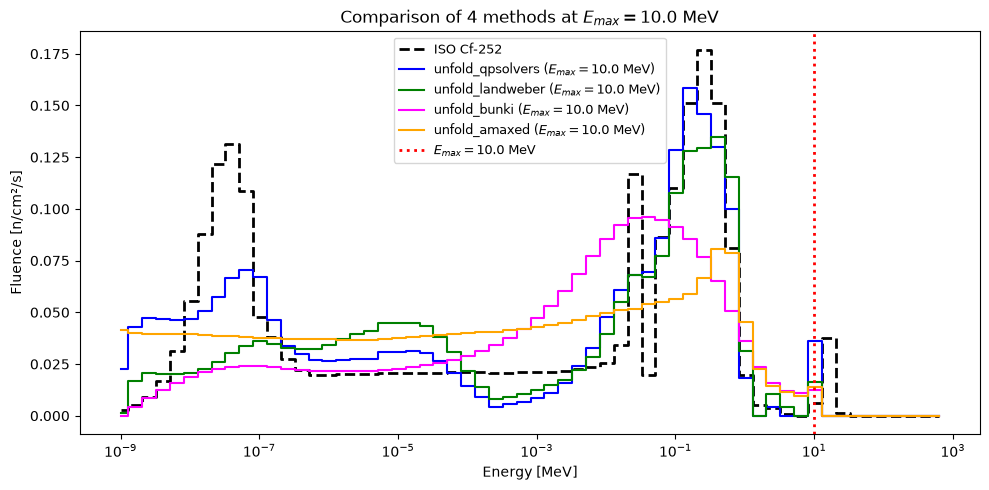

In [29]:
emax = 10.0
fig, ax = plt.subplots(figsize=(10, 5))

ax.step(det.E_MeV, spectrum_true, 'k--', lw=2, label='ISO Cf-252', where='mid')

for name, color in [
    ('unfold_qpsolvers', 'blue'),
    ('unfold_landweber', 'green'),
    ('unfold_bunki',     'magenta'),
    ('unfold_amaxed',    'orange'),
]:
    res = getattr(det, name)(readings, max_neutron_energy=emax)
    ax.step(det.E_MeV, res['spectrum'], '-', color=color, lw=1.5,
            label=f'{name} ($E_{{max}}={emax}$ MeV)', where='mid')

ax.axvline(emax, color='red', ls=':', lw=2, label=f'$E_{{max}}={emax}$ MeV')
ax.set_xscale('log')
ax.set_xlabel('Energy [MeV]')
ax.set_ylabel('Fluence [n/cm²/s]')
ax.set_title(f'Comparison of 4 methods at $E_{{max}} = {emax}$ MeV')
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

## Numerical check: fluence above $E_{\max}$ must be zero

In [30]:
for method in ['unfold_qpsolvers', 'unfold_landweber', 'unfold_bunki', 'unfold_amaxed']:
    res = getattr(det, method)(readings, max_neutron_energy=20.0)
    above = res['spectrum'][det.E_MeV > 20.0]
    print(f'{method:25s}  max fluence above 20 MeV: {above.max():.2e}')

unfold_qpsolvers           max fluence above 20 MeV: 0.00e+00
unfold_landweber           max fluence above 20 MeV: 0.00e+00
unfold_bunki               max fluence above 20 MeV: 0.00e+00
unfold_amaxed              max fluence above 20 MeV: 0.00e+00
